# INF8111 - Fouille de données 
## Été 2026 - TP1 - Préparation des données de séries temporelles-Consommation électrique
### Membres de l'équipe 
    - Kouassi, Kylian - 2194817
    - Yandjeu Nana, Ariel De Guilique - 2495529
    - Bantsimbas, Evan - 2450586


## Instructions de remise 

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP1\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **24 mai 2026 à 23h59***. À l'ouverture du Notebook, toutes les réponses doivent être visibles. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

    Partie 1: 20 points
    
    Partie 2: 30 points
    
    Partie 3: 50 points
    
    Pour un total de 100 points.

## Séries temporelles 

Les séries temporelles sont de plus en plus utilisées dans plusieurs domaines tels aue la finance, la météorologie, la santé et la gestion de l'énergie pour modéliser, analyser et prévoir des phénomènes évolutifs. Une série temporelle correspond à une suite d’observations ordonnées dans le temps, collectées à intervalles réguliers ou irréguliers (par exemple : prix journaliers d’une action, température horaire, consommation électrique, etc.). 
Ces données présentent une structure particulière caractérisée par la dépendance entre les observations successives. À partir de ces données temporelles, il devient possible d’identifier des tendances à long terme, des cycles saisonniers, ainsi que des anomalies ou événements inhabituels. Par exemple, en finance, elles servent à anticiper les fluctuations des marchés ; en météorologie, à prévoir les conditions climatiques ; en santé, à suivre l’évolution de paramètres physiologiques ; et dans l’énergie, à optimiser la production ou la consommation.

    
### But
Le but de ce TP est de vous donner un aperçu de la fouille de données dans le cas des séries temporelles. En raison des crises énergétiques, des études de fouille et d'analyse de données peuvent être faites afin de prendre des décisions qui favorisent une consommation optimale de l'énergie électrique. Le but de ce TP est d'extraire des informations pertinentes à partir des données de consommation d'énergie électrique qui sont fournies. 

### Importation des différents modules 

In [56]:
# Installation des librairies 

#!pip install pandas
#!pip install numpy
#!pip install scikit-learn
#!pip install seaborn
#!pip install matplotlib
#!pip install plotly
#!pip install statsmodels

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Informations sur les données 
Nous vous avons fourni le fichier data.csv avec l'exécution de cellule suivante. Il contient l'ensemble des données. Il s'agit des mesures collectées dans une maison située à Sceaux (à 7 km de Paris, France) entre décembre 2006 et novembre 2010. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name           | Description |
|---|------------------------|-------------|
| 1 | Date                  | Date / Date au format jj/mm/aaaa |
| 2 | Time                  | Heure / Heure au format hh:mm:ss |
| 3 | Global_active_power   | Puissance active globale / Household global minute-averaged active power (in kilowatt) |
| 4 | Global_reactive_power | Puissance réactive globale / Household global minute-averaged reactive power (in kilowatt) |
| 5 | Voltage               | Tension / Minute-averaged voltage (in volt) |
| 6 | Global_intensity      | Intensité globale / Household global minute-averaged current intensity (in ampere) |
| 7 | Sub_metering_1        | Sous-comptage 1 / Energy sub-metering No. 1 (cuisine : lave-vaisselle, four, micro-ondes) |
| 8 | Sub_metering_2        | Sous-comptage 2 / Energy sub-metering No. 2 (buanderie : machine à laver, sèche-linge, réfrigérateur, lumière) |
| 9 | Sub_metering_3        | Sous-comptage 3 / Energy sub-metering No. 3 (chauffage électrique et climatisation) |

Notons que (global_active_power×1000/60−sub_metering_1−sub_metering_2−sub_metering_3) représente l’énergie active consommée chaque minute (en watt-heure) dans le foyer par les équipements électriques non mesurés par les sous-compteurs 1, 2 et 3.

In [58]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"],low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 1. Nettoyage et préparation de données (5 points)

#### Question 1.1 ( 2 points)
**Combien d'observations contient le dataset ? 

In [59]:
# TO DO
print("Nombre d'observations du dataset:", df.shape[0])

Nombre d'observations du dataset: 2075259


#### Question 1.2 (3 points)

Supprimer les lignes ayant des valeurs manquantes puis indiquer le nombre de lignes supprimées.  

In [60]:
# TO DO

new_df=df.dropna()

print("Nombre de lignes supprimé =", len(df)-len(new_df))



Nombre de lignes supprimé = 25979


####  Question 1.3 (4 points)
En visualisant les colonnes du dataset, et en se référant à la description fournie, quels sont les attributs numériques?

In [61]:
# TO DO ( aucun code n'est requis pour répondre à  cette question)

### Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_metering_1, Sub_metering_2, Sub_metering_3

#### Question 1.4 (5 points) 

On veut combiner les colonnes **Date** et **Time** pour créer une seule variable temporelle **dt**, représentant l’instant exact de chaque observation. La colonne **dt** doit être au format **aaaa-mm-jj hh:mm:ss**. Transformez les colonnes **Date** et **Time** en **dt**.

In [62]:
# TO DO
cleaned_df=new_df.copy()
cleaned_df["dt"] = pd.to_datetime(cleaned_df["Date"] + " " + cleaned_df["Time"], format="%d/%m/%Y %H:%M:%S")
cleaned_df.pop("Date")
cleaned_df.pop("Time")
cleaned_df.insert(0, "dt", cleaned_df.pop("dt"))
cleaned_df.head()

,dt,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


#### Question 1.5 (7,5 points)
a - Afficher la matrice de corrélation entre les différents attributs numériques de nos données. Quelle sont les paires d'attributs fortement correlés ? Utiliser un seuil de 0,75. 

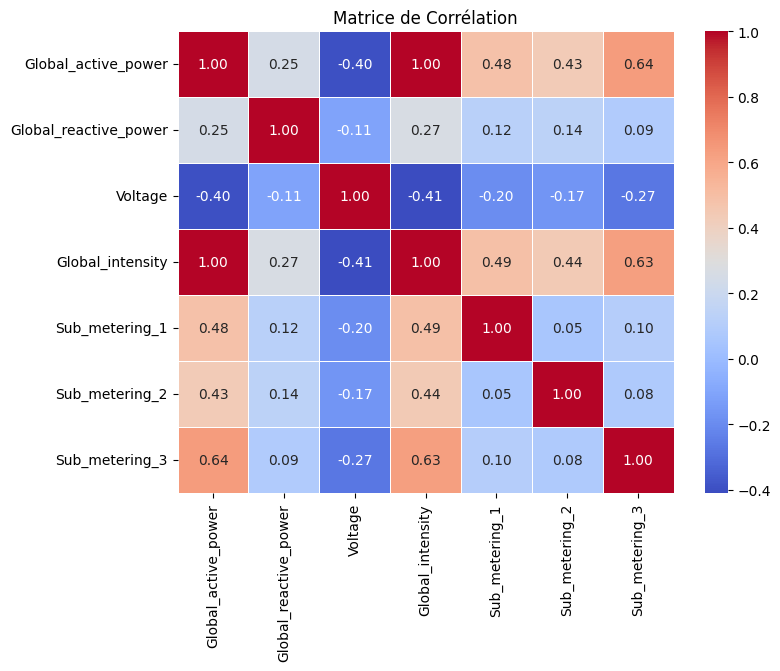


Paires d'attributs fortement corrélés (seuil absolu > 0.75) :
Global_active_power-Global_intensity:1.00


In [63]:
# TO DO
correlation_matrix=(cleaned_df.drop(columns=["dt"])).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

threshold=0.75
print("\nPaires d'attributs fortement corrélés (seuil absolu > 0.75) :")

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value=correlation_matrix.iloc[i, j]
        if abs(corr_value)>threshold:
            col1=correlation_matrix.columns[i]
            col2=correlation_matrix.columns[j]

            print (f"{col1}-{col2}:{corr_value:.2f}")

b- Afficher sur un graphe la relation entre les deux attributs ayant la plus forte corrélation. 

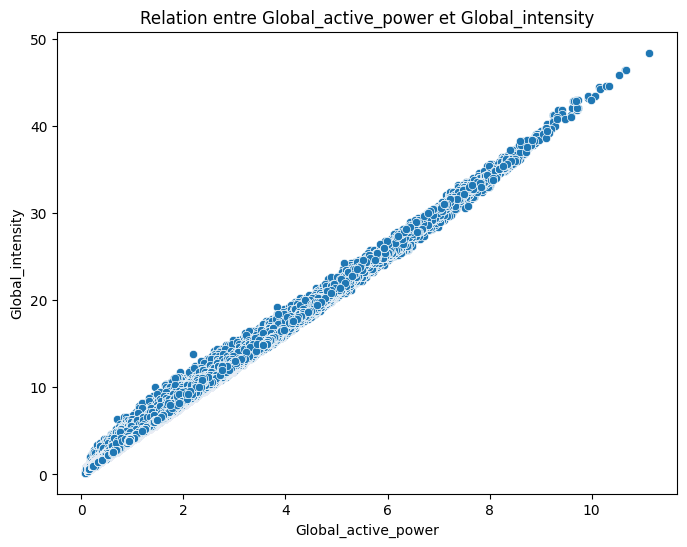

In [64]:
# TO DO
plt.figure(figsize=(8,6))
sns.scatterplot(data=cleaned_df, x=col1, y=col2)
plt.title(f"Relation entre {col1} et {col2}")
plt.show()

# 2. Prédiction standard
De façon classique, un modèle de prédiction indique une relation entre des variables d'entrée et une variable à prédire. Dans cette partie, nous allons prédire  **Global_active_power** en utilisant les autres colonnes.

#### Question 2.1   (5 points)
Pour l'ensemble des données, créer un ensemble de données nommé **data** en remplaçant la colonne **dt** par de nouvelles colonnes **annee**, **mois**, **jour**, **heure** et **minutes**. 
Indiquer pourquoi la colonne **secondes** peut être ignorée pour notre ensemble de données. 

In [74]:
# TO DO
data = cleaned_df.copy()

data.insert(0, "Jour", data["dt"].dt.day)
data.insert(1, "Mois", data["dt"].dt.month)
data.insert(2, "Annee", data["dt"].dt.year)
data.insert(3, "Heure", data["dt"].dt.hour)
data.insert(4, "Minutes", data["dt"].dt.minute)
data.pop("dt")
data.head()

,Jour,Mois,Annee,Heure,Minutes,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16,12,2006,17,24,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16,12,2006,17,25,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16,12,2006,17,26,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16,12,2006,17,27,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16,12,2006,17,28,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### La colonne secondes peut être ignorée car toutes les secondes sont nulles

#### Question 2.2 (5 points)
On peut normaliser les données. 

*   La `standardisation` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `Min-Max Scaling` normalise les données en les ramenant entre 0 et 1.

Réaliser la normalisation des données par `standardisation`. On peut utiliser la fonction `StandardScaler()` de `sklearn`.

In [75]:
# TO DO
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_array=scaler.fit_transform(data)
df_scaled=pd.DataFrame(scaled_array, columns=data.columns)
print(df_scaled.head())

       Jour      Mois     Annee     Heure   Minutes  Global_active_power  \
0  0.032669  1.619991 -2.156517  0.793638 -0.317616             2.955077   
1  0.032669  1.619991 -2.156517  0.793638 -0.259872             4.037085   
2  0.032669  1.619991 -2.156517  0.793638 -0.202128             4.050326   
3  0.032669  1.619991 -2.156517  0.793638 -0.144384             4.063567   
4  0.032669  1.619991 -2.156517  0.793638 -0.086641             2.434881   

   Global_reactive_power   Voltage  Global_intensity  Sub_metering_1  \
0               2.610721 -1.851816          3.098789       -0.182337   
1               2.770406 -2.225274          4.133800       -0.182337   
2               3.320432 -2.330213          4.133800       -0.182337   
3               3.355917 -2.191324          4.133800       -0.182337   
4               3.586573 -1.592556          2.513782       -0.182337   

   Sub_metering_2  Sub_metering_3  
0       -0.051274        1.249421  
1       -0.051274        1.130897  
2 

#### Question 2.3 (5 points)
On va séparer les données en un ensemble d'entraînement et un ensemble de feat_test qu'on va nommer respectivement 'data_train' et 'data_test'. Utiliser les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le feat_test.

Effectuer la séparartion des données.

In [77]:
# TO DO
data_train=data[data["Annee"]<=2009].copy()
data_test=data[data["Annee"]==2010].copy()

data_test.head()

,Jour,Mois,Annee,Heure,Minutes,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1600236,1,1,2010,0,0,1.790,0.236,240.65,7.4,0.0,0.0,18.0
1600237,1,1,2010,0,1,1.780,0.234,240.07,7.4,0.0,0.0,18.0
1600238,1,1,2010,0,2,1.780,0.234,240.15,7.4,0.0,0.0,19.0
1600239,1,1,2010,0,3,1.746,0.186,240.26,7.2,0.0,0.0,18.0
1600240,1,1,2010,0,4,1.686,0.102,240.12,7.0,0.0,0.0,18.0


### Question 2.4 - Entrainement de modèle de régression linéaire

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Il consiste à trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `Global_active_power`.

La métrique RMSE (Root Mean Square Error) est une métrique utilisée pour mesurer la différence moyenne entre les valeurs prédites par un modèle et les valeurs observées.

#### Question 2.4.1 (10 points )
Entrainer un modèle de regresion linéaire avec **data_train** et  calculer la RMSE correspondante aux données de l'ensemble de feat_test.

In [78]:
# TO DO
from sklearn.linear_model import LinearRegression
temp_data_train=data_train.copy()
y_train=temp_data_train["Global_active_power"]
X_train= temp_data_train.drop(columns=["Global_active_power", "Jour", "Mois", "Annee", "Heure", "Minutes"])
model=LinearRegression()
model.fit(X_train, y_train)

temp_data_test=data_test.copy()
y_test=temp_data_test["Global_active_power"]
X_test=temp_data_test.drop(columns=["Global_active_power", "Jour", "Mois", "Annee", "Heure", "Minutes"])

predictions=model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, predictions))

print(rmse)

0.03948597852123942


La prédiction est obtenue. On peut maintenant mesurer l'importance de chaque attribut dans la prédicition en se référant aux coefficients de la régression linéaire.
#### Question 2.4.2  (5 points)
Quels sont les trois attributs ayant le plus d'impact dans la prédiction ?

In [79]:
impact_df=pd.DataFrame({
    'Attribut': X_train.columns,
    'Coefficient': model.coef_
})

impact_df['Impact']=impact_df['Coefficient'].abs()
top3=impact_df.sort_values(by='Impact', ascending=False).head(3)
print(f"Les trois attributs ayant le plus d'impact dans la prédiction sont: .\n {top3}")

Les trois attributs ayant le plus d'impact dans la prédiction sont: .
                 Attribut  Coefficient    Impact
2       Global_intensity     0.237942  0.237942
0  Global_reactive_power    -0.173153  0.173153
1                Voltage     0.004376  0.004376


In [80]:
# On copie les données pour les utiliser dans la partie 3. 
dft = df.copy()

# 3. Prédiction de série temporelle 
Dans la partie précédente, la prédiction d'une valeur nécessite la connaissance des valeurs des autres attributs de l'observation concernée. On n'a pas toujours ces valeurs et pourtant on peut faire de prédiction dans ces situations. Les séries temporelles sont plus adaptées dans ces situations. La prédiction de séries temporelles consiste à estimer les valeurs futures d’une variable en se basant sur ses observations passées. 

Dans la suite du TP, seuls les attributs **Global_active_power** et **dt** vont être utilisés. La cellule suivante permet de réduire les données.

In [81]:
# Exécuter ce code pour afficher les données obtenues.
# Si la colonne 'dt' n'apparait pas en 'indice', vous pouvez l'ajouter ici.
dft=df.copy()
dft["dt"]= dft["Date"].astype(str)+ " "+dft["Time"].astype(str)
dft["dt"]=pd.to_datetime(dft["dt"], format='%d/%m/%Y %H:%M:%S')
dft=dft.set_index('dt')
dft = dft["Global_active_power"]
dft

dt
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2075259, dtype: float64

## 3.1 Analyse préliminaire des données

#### Question 3.1.1 ( 3 points)
Calculer et afficher sur un graphe la consommation moyenne de **Global_active_power** pour chaque mois de l'année.

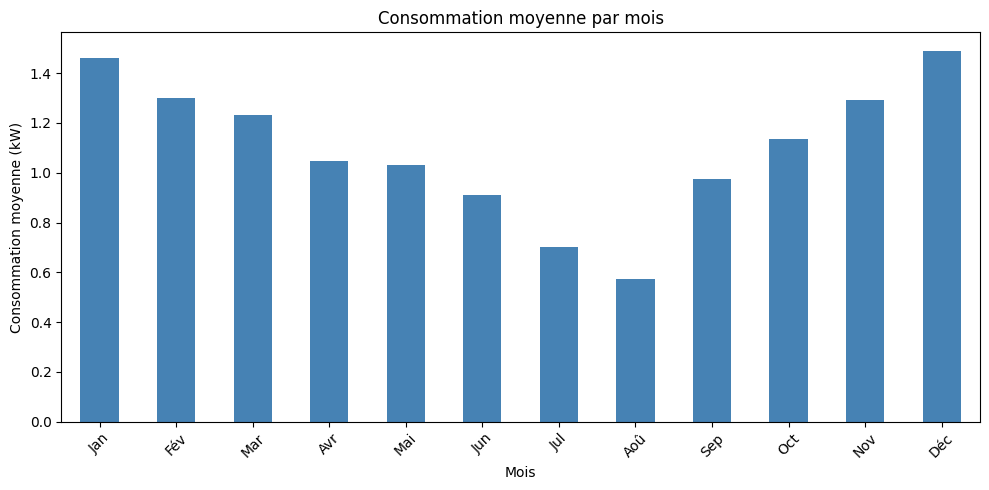

In [82]:
# TO DO
moyenne=dft.groupby(dft.index.month).mean()
plt.figure(figsize=(10, 5))
moyenne.plot(kind='bar', color='steelblue')
plt.xlabel('Mois')
plt.ylabel('Consommation moyenne (kW)')
plt.title("Consommation moyenne par mois")
plt.xticks(range(12), ['Jan','Fév','Mar','Avr','Mai','Jun',
                        'Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=45)
plt.tight_layout()
plt.show()

Les données fournies sont en minutes. Pour la suite du TP, on va réduire la taille des données en faisant un rééchantillonnage des données en utilisant la somme par jour. La cellule suivante permet de faire cette réduction et de visualiser les données obtenues.

<Axes: xlabel='dt'>

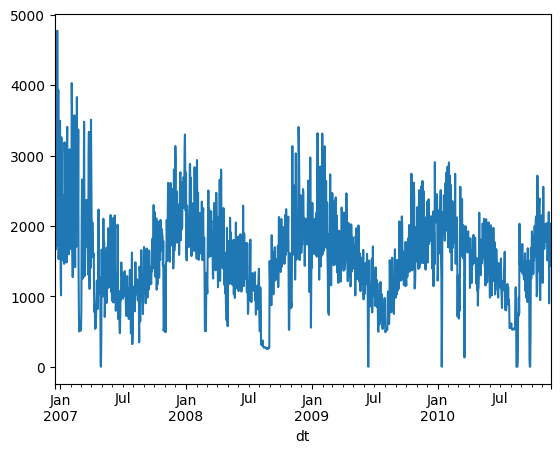

In [83]:
# Exécuter ce code pour afficher les données réduites
df_journalier = dft.resample('D').sum()
df_journalier.plot()

#### Question 3.1.2 (3 points)
En utilisant la fonction **seasonal_decompose** de la librairie **statsmodels**, effectuer une décomposition de la série temporelle journalière (df_journalier) avec une période de 6 mois.

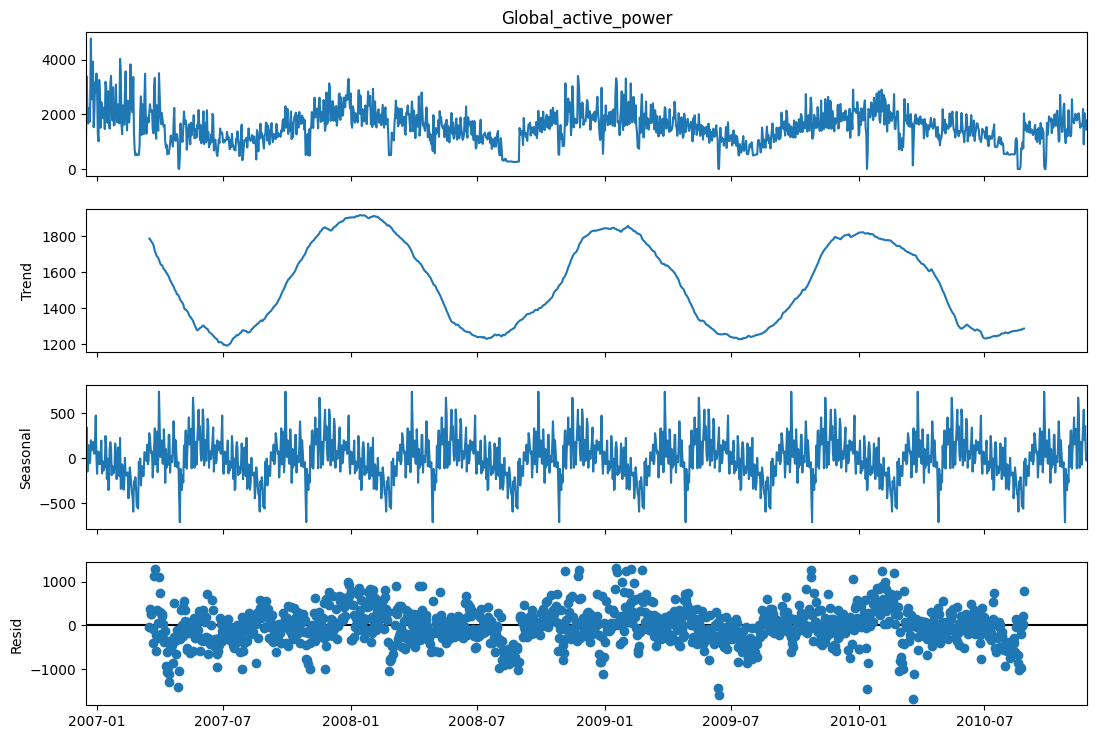

In [84]:
# TO DO
decomposition=seasonal_decompose(df_journalier, model='additive', period=round(365/2))
fig=decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

#### Question 3.1.3 (4 points)
Interpréter les résultats obtenus aux questions 3.1.1 et 3.1.2. 
    Quelle périodicité observe-t-on ? 
    Quels mois présentent une consommation plus élevée ?
    Cette information est-elle cohérente avec un usage domestique ?

In [85]:
# TO DO  

### On constate qu'à chaque fois la consommation baisse fortement au milieu de l'année (pendant l'été) et on observe aussi une baisse fréquente à chque début début d'année (Janvier). Donc la périodicité est de 1 an. Les mois présentant une consommation plus élevée sont le mois de Janvier et de Décembre. Ces interprétations sont cohérentes avec un usage domestique car le mois de décembre est un mois froid qui requiert plus de consommation d'énergie (chauffage)

#### Question 3.1.4 (3 points)
Les **lag features** sont très utilisées dans la prédiction des séries temporelles. Elles permettent de saisir les tendances temporelles des données en générant de nouvelles variables à partir des valeurs passées. Ces variables permettent d'utiliser les valeurs passées pour prédire les valeurs futures. Par exemple, la prédiction de la consommation d'aujourd'hui pourrait dépendre de la consommation du même jour de l'année passée. Dans ce cas, la consommation d'il y a un an constituerait une lag feature.
Vous pouvez consulter le [lien](https://www.kaggle.com/code/ryanholbrook/time-series-as-features/tutorial) suivant pour un apperçu du lag embedding. 


Quelle valeur est adéqate pour une variable lagged dans ce cas ? Justifier votre réponse.

In [86]:
# TO DO (aucun code n'est requis pour répondre à cette question)

### La valeur adéquate pour une variable lagged est de 365 jours car les données échantillonnées par jour permettrait donc au modèle de comparer la valeur de la consommation actuelle avec celle de l'année dernière.

### 3.2  Modèle de régression linéaire 
Nous allons appliquer la régression linéaire sur nos données réduites. Pour cela, on doit transformer le problème de séries temporelles en un problème d'apprentissage supervisé. On va créer des "lagged features" pour accomplir cette tâche, puis diviser les données obtenues en des ensembles d'apprentissage et de feat_test, respectivement les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le feat_test. 

#### Question 3.2 (12.5 points)
Entraîner un modèle de regresion linéaire dans ce cas. Pour cela, créer une variable 'lags' permettant de garder en mémoire à chaque jour la consommation d'un jour du passé. Calculer la RMSE correspondante aux données prédites. 

In [87]:
# TO DO
lags=df_journalier.copy()
lags=lags.shift(365)
lags=lags.dropna()


lags.index = pd.to_datetime(lags.index, format='%Y-%m-%d')

lags_train=lags[lags.index.year<=2009].copy()
lags_test=lags[lags.index.year==2010].copy()

X_train1=lags_train.to_numpy().reshape(-1,1)
X_test1=lags_test.to_numpy().reshape(-1,1)

y_train1=df_journalier.loc[lags_train.index].to_numpy()
y_test1=df_journalier.loc[lags_test.index].to_numpy()

model1=LinearRegression()
model1.fit(X_train1, y_train1)

y_pred1=model1.predict(X_test1)

rmse1=np.sqrt(mean_squared_error(y_test1, y_pred1))

rmse1

np.float64(500.8605793047217)

### 3.3 Entrainement d'un modèle au choix
#### Question 3.3 (12.5 points)
Pour les mêmes périodes de sous-ensembles de données, entrainer un modèle de votre choix et calculer la RMSE correspondante. Justifiez votre choix.

Toute tranformation des données réduites avant l'entrainement est autorisée ici. L'obtention d'un RMSE meilleur au précédent sera valorisée. 

In [88]:
# TO DO
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def make_features(series):
    df = pd.DataFrame({"Global_active_power": series})

    # Lags
    for lag in [1, 2, 7, 14, 30, 365]:
        df[f"lag_{lag}"] = df["Global_active_power"].shift(lag)

    # Stats glissantes (shift(1) pour éviter toute fuite: on n’utilise pas y(t) pour prédire y(t))
    df["roll7_mean"] = df["Global_active_power"].shift(1).rolling(7).mean()
    df["roll30_mean"] = df["Global_active_power"].shift(1).rolling(30).mean()

    return df.dropna()

feat = make_features(df_journalier)


feat_train = feat[feat.index.year <= 2009]
feat_test  = feat[feat.index.year == 2010]

X_train2 = feat_train.drop(columns=["Global_active_power"])
y_train2 = feat_train["Global_active_power"]
X_test2  = feat_test.drop(columns=["Global_active_power"])
y_test2  = feat_test["Global_active_power"]

model2 = RandomForestRegressor(
    n_estimators=500,
    random_state=0,
    n_jobs=-1
)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
print(f"RMSE={rmse2}")


RMSE=392.0395956458453


#### Nous avons opté pour un enrichissement de données accompagné d'un algorithme RandomForestRegressor dans le but de capturer la non-linéarité et de réduire le surapprentissage grâce à l'agrégation de plusieurs arbres. Avec plusieurs lags (1, 2, 7, 14, 30, 365) et des moyennes glissantes, le modèle dispose d’un contexte temporel plus riche.

### 3.4 Évaluation des deux modèles 

#### Question 3.4.1 (7 points)
Pour chacun des deux modèles précédents, afficher sur une figure les observations réelles de **Global_active_power** et celles prédites en fonction du temps pour l'année 2010.

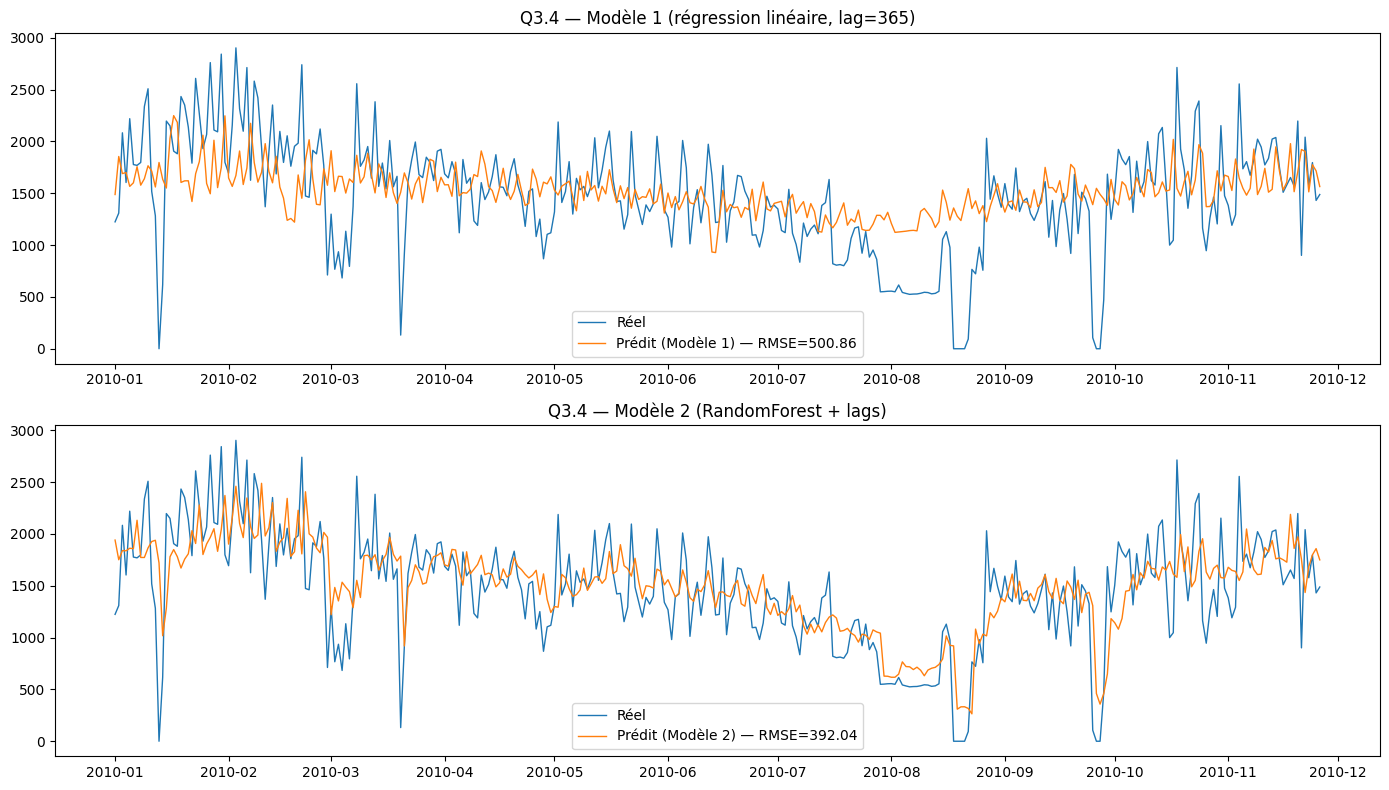

In [89]:

# Axe temps pour le modèle 1: y_test1/y_pred1 sont des numpy.ndarray
if "lags_test" in globals() and hasattr(lags_test, "index"):
    x1 = lags_test.index
else:
    x1 = np.arange(len(y_test1))

y1 = np.asarray(y_test1).ravel()
yhat1 = np.asarray(y_pred1).ravel()

# Axe temps pour le modèle 2: y_test2 est une Series indexée
if hasattr(y_test2, "index"):
    x2 = y_test2.index
else:
    x2 = np.arange(len(y_test2))

y2 = np.asarray(y_test2).ravel()
yhat2 = np.asarray(y_pred2).ravel()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(x1, y1, label="Réel", linewidth=1)
axes[0].plot(x1, yhat1, label=f"Prédit (Modèle 1) — RMSE={rmse1:.2f}", linewidth=1)
axes[0].set_title("Q3.4 — Modèle 1 (régression linéaire, lag=365)")
axes[0].legend()

axes[1].plot(x2, y2, label="Réel", linewidth=1)
axes[1].plot(x2, yhat2, label=f"Prédit (Modèle 2) — RMSE={rmse2:.2f}", linewidth=1)
axes[1].set_title("Q3.4 — Modèle 2 (RandomForest + lags)")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Question 3.4.2  (5 points)
En se basant sur les graphes obtenus à la question précédente et sur les RMSE obtenus pour les deux modèles, faites une analyse comparative des résultats. 

In [90]:
# TO DO ( aucun code n'est requis pour répondre à  cette question)

## Analyse comparative (année 2010)

#### RMSE Modèle 1 =500,86

#### RMSE Modèle 2 =392,04

Les graphes de prédiction montrent la tendance générle de la consommation. Toutefois on remarque que le modèle 2 présente un faible écart entre les valeurs prédites et lees valeurs réelles. Contrairement au modèle1 où il présente davatage d'écarts par rapport aux données observées.
(RMSE1 -RMSE2)/RMSE1 = 21,7% 
Ce calcul nous permet donc de comprendre que le Modèle 2 réduit l'erreur de prédiction d'environ 22% par rapoort au Modèle 1.

### Conclusion :
Le modèle 2 offre de meilleures performances pour la prédiction de la consommation électrique en 20210.